In [3]:
import torch
import pickle
import pandas as pd
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import numpy as np

import os

from os import listdir
from os.path import isfile, join
import yaml
from dl_components.pl_wrappers import Architecture_PL

import sys
sys.path.append("..")
from robustness_experiments.plot import renames, ordering, rename_labels,exp_ordering

from sklearn.metrics import (
    roc_auc_score,
)

import pandas as pd

import seaborn as sns
import matplotlib
import os
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 10


# Sanity check. 

Controls for consistency between ensemble and robustness experiments

In [ ]:
# See if this is still valid with the Individual Scoring.

# Newly processed runs
p = "ensemble_experiments/release_ensemble_summarized_results/sanity_check/small/direct_crosscorr/scores.csv"
# Main runs (we exported results for only the small data regime via TCD-Arena functionality)
p3 = "robustness_experiments/release_summarized_supplementary_results/performance_export_comparison_small/mean/correct_lag/WCG/SHD individual/highest_hps.csv"
p4 = "robustness_experiments/release_summarized_supplementary_results/performance_export_comparison_small/mean/correct_lag/INST/SHD individual/highest_hps.csv"
p5 = "robustness_experiments/release_summarized_supplementary_results/performance_export_comparison_small/mean/correct_lag/SG_max/SHD individual/highest_hps.csv"


sanity = pd.read_csv(p,index_col=0)
sanity = sanity[sorted(sanity.columns)]

sanity.columns = [x.replace("_small","") for x in sanity.columns]

b = pd.read_csv(p3,index_col=0)["direct_crosscorr"].sort_index()
c = pd.read_csv(p4,index_col=0)["dynotears"].sort_index()
d = pd.read_csv(p5,index_col=0)["direct_crosscorr"].sort_index()


In [9]:
# Numerical differences but identical
sanity.mean(axis=1)["WCG"] - b.mean(), sanity.mean(axis=1)["INST"] - c.mean(), sanity.mean(axis=1)["SG_max"] - d.mean()

(1.1102230246251565e-16, 1.3970725776246695e-05, 1.1102230246251565e-16)

# Comparison results to main section 

In [ ]:
b1 = "robustness_experiments/release_summarized_results/performance_export/mean/correct_lag/WCG/SHD individual/highest_hps.csv"
b2 = "robustness_experiments/release_summarized_results/performance_export/mean/correct_lag/INST/SHD individual/highest_hps.csv"
b3 = "robustness_experiments/release_summarized_results/performance_export/mean/correct_lag/SG_max/SHD individual/highest_hps.csv"

In [13]:
base1 = pd.read_csv(b1,index_col=0)
base2 = pd.read_csv(b2,index_col=0)
base3 = pd.read_csv(b3,index_col=0)
pd.concat([base1.mean(axis=0),base2.mean(axis=0),base3.mean(axis=0)],axis=1)

,0,1,2
cp,0.530250,NaN,0.440440
pcmci,0.601465,NaN,0.447320
ntsnotears,0.444679,0.673804,0.358432
pcmciplus,0.538715,0.997591,0.405259
varlingam,0.408316,0.692182,0.333818
dynotears,0.444502,0.514900,0.365074
fpcmci,0.499220,0.657383,0.434164
svarrfci,0.517249,0.997429,0.406922
var,0.423668,NaN,0.329706
direct_crosscorr,0.582062,NaN,0.452753


# Mean ensemble

In [ ]:
p = "ensemble_experiments/release_ensemble_summarized_results/mean_predictions/small/scores.csv"
p2 = "ensemble_experiments/release_ensemble_summarized_results/mean_predictions/big/scores.csv"

mean_ensemble = pd.read_csv(p,index_col=0)
mean_ensemble_big = pd.read_csv(p2,index_col=0)
mean_results = pd.concat([mean_ensemble, mean_ensemble_big],axis=1)
mean_results.columns = [x.replace("_small","") for x in mean_results.columns]
mean_results.mean(axis=1).round(3),mean_results.std(axis=1).round(2)

(SG_max     0.300
 WCG        0.387
 SG_mean    0.361
 INST       0.550
 dtype: float64,
 SG_max     0.24
 WCG        0.30
 SG_mean    0.23
 INST       0.23
 dtype: float64)

## Pareto Front


In [ ]:
b1 = "robustness_experiments/release_summarized_results/performance_export/mean/correct_lag/WCG/SHD individual/highest_hps.csv"
b2 = "robustness_experiments/release_summarized_results/performance_export/mean/correct_lag/INST/SHD individual/highest_hps.csv"
b3 = "robustness_experiments/release_summarized_results/performance_export/mean/correct_lag/SG_max/SHD individual/highest_hps.csv"

In [43]:
a = pd.read_csv(b1,index_col=0)
b = pd.read_csv(b2,index_col=0)
c = pd.read_csv(b3,index_col=0)

In [44]:
print(a.min(axis=1).mean(),a.min(axis=1).std())
print(b.min(axis=1).mean(),b.min(axis=1).std())
print(c.min(axis=1).mean(),c.min(axis=1).std())

0.3756819551502273 0.29333461587736354
0.47001169929554076 0.26709115012573587
0.2956269518035822 0.23565986614151163


# Trained ensemble

In [ ]:
# 3 ensembles for both sizes

p1 = "ensemble_experiments/release_ensemble_summarized_results/ensemble_predictions/SimpleLinear/small/scores.csv"
p2 = "ensemble_experiments/release_ensemble_summarized_results/ensemble_predictions/SimpleLinear/big/scores.csv"
p3 = "ensemble_experiments/release_ensemble_summarized_results/ensemble_predictions/SimpleMLP/small/scores.csv"
p4 = "ensemble_experiments/release_ensemble_summarized_results/ensemble_predictions/SimpleMLP/big/scores.csv"
p5 = "ensemble_experiments/release_ensemble_summarized_results/ensemble_predictions/SimpleTransformer/small/scores.csv"
p6 = "ensemble_experiments/release_ensemble_summarized_results/ensemble_predictions/SimpleTransformer/big/scores.csv"

In [18]:
linear = ((pd.read_csv(p1,index_col=0) + pd.read_csv(p2,index_col=0).values) /2)
linear.columns = [x.replace("_small","") for x in linear.columns]

In [19]:
mlp = ((pd.read_csv(p3,index_col=0) + pd.read_csv(p4,index_col=0).values) /2)
mlp.columns = [x.replace("_small","") for x in mlp.columns]

In [20]:
transformer = ((pd.read_csv(p5,index_col=0) + pd.read_csv(p6,index_col=0).values) /2)
transformer.columns = [x.replace("_small","") for x in transformer.columns]

In [21]:
ensembles = pd.concat([linear.mean(axis=1).round(3),linear.std(axis=1).round(2),mlp.mean(axis=1).round(3),mlp.std(axis=1).round(2),transformer.mean(axis=1).round(3),transformer.std(axis=1).round(2)], axis=1)
ensembles.columns = ["Linear Mean", "Linear Std", "MLP Mean", "MLP Std", "Transformer Mean", "Transformer Std"]
ensembles

,Linear Mean,Linear Std,MLP Mean,MLP Std,Transformer Mean,Transformer Std
SG_max,0.281,0.16,0.343,0.15,0.324,0.16
WCG,0.362,0.20,0.445,0.18,0.415,0.20
SG_mean,0.321,0.15,0.438,0.12,0.392,0.13
INST,0.527,0.19,0.523,0.20,0.587,0.16


# Generate Heatmap of improvements

In [50]:
def create_gains_heatmap(a, which="INST",name="INST"):
    a["Ensemble (Mean)"] = mean_results[a.index].loc[which].values
    a["Ensemble (Linear)"] = linear[a.index].loc[which].values
    a["Ensemble (MLP)"] = mlp[a.index].loc[which].values
    a["Ensemble (Transformer)"] = transformer[a.index].loc[which].values
    a
    # substract the column direct_crosscorr from all other columns
    if which == "INST":
        a = a.subtract(a["pcmciplus"], axis=0)
    else:
        a = a.subtract(a["direct_crosscorr"], axis=0)
    a = a.loc[exp_ordering]
    a.index = [rename_labels[x] for x in a.index]
    a.columns = [renames[x]if x in renames.keys() else x for x in a.columns ]
    a = a[[x for x in ordering if x in a.columns] + ["Ensemble (Mean)","Ensemble (Linear)","Ensemble (MLP)","Ensemble (Transformer)"]].round(3).T
    a = a* -1 # gains
    plt.figure(figsize=(18, 7))
    sns.heatmap(a, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
                cbar_kws={'label': r'Performance difference from $\mathtt{CrossCorr}$'},
                linewidths=0.5, linecolor='gray')
    plt.title(r'\textbf{Robustness Gains as SHD Reduction (vs CrossCorrelation Baseline) for $\textbf{G}^{' + name + r'}$}', fontsize=14, pad=20)
    plt.xlabel(r'\textbf{Violation}', fontsize=12)
    plt.ylabel(r'\textbf{Method}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    os.makedirs('img', exist_ok=True)
    plt.savefig(f'img/robustness_{which}_heatmap.pdf', bbox_inches='tight', dpi=300)
    plt.show()

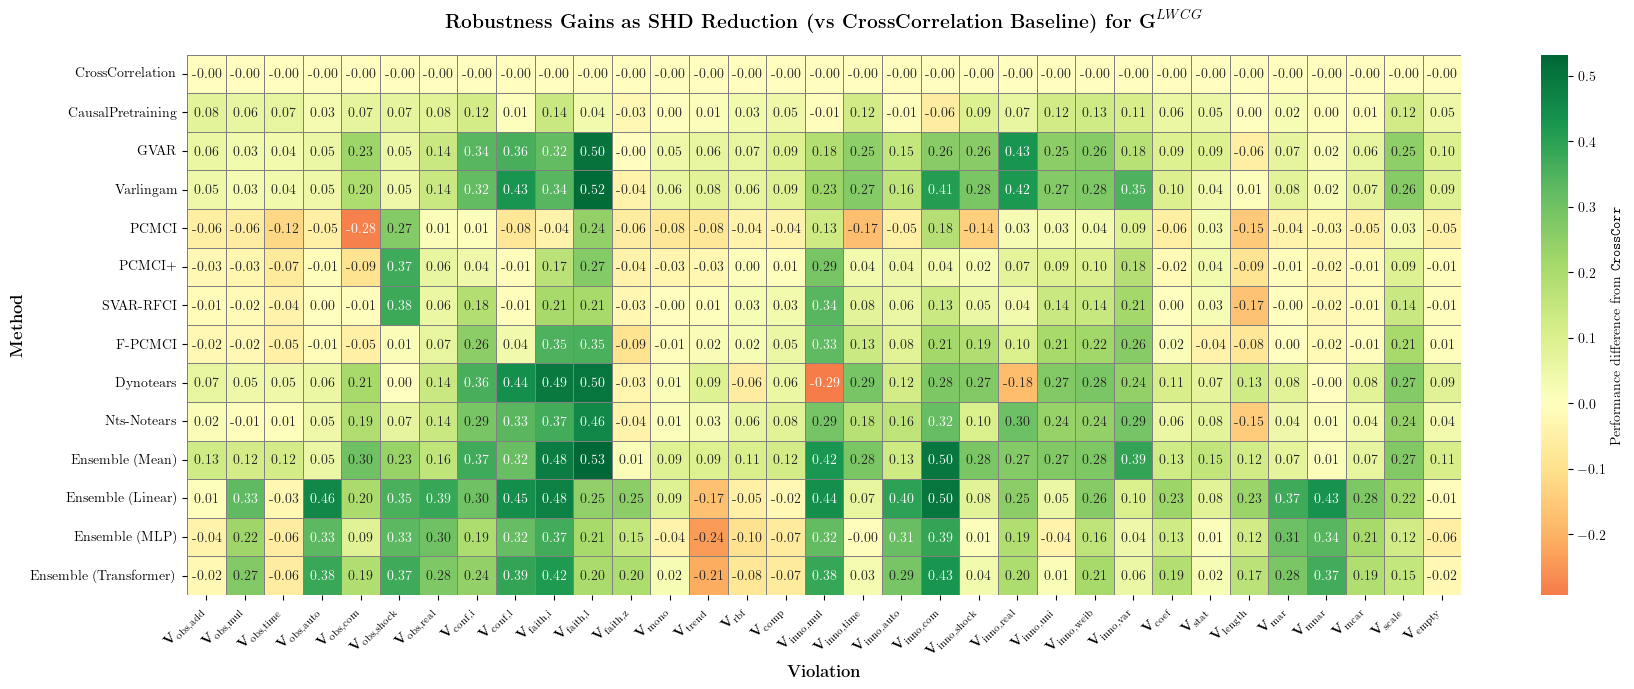

In [51]:
create_gains_heatmap(base1,which="WCG",name="LWCG")

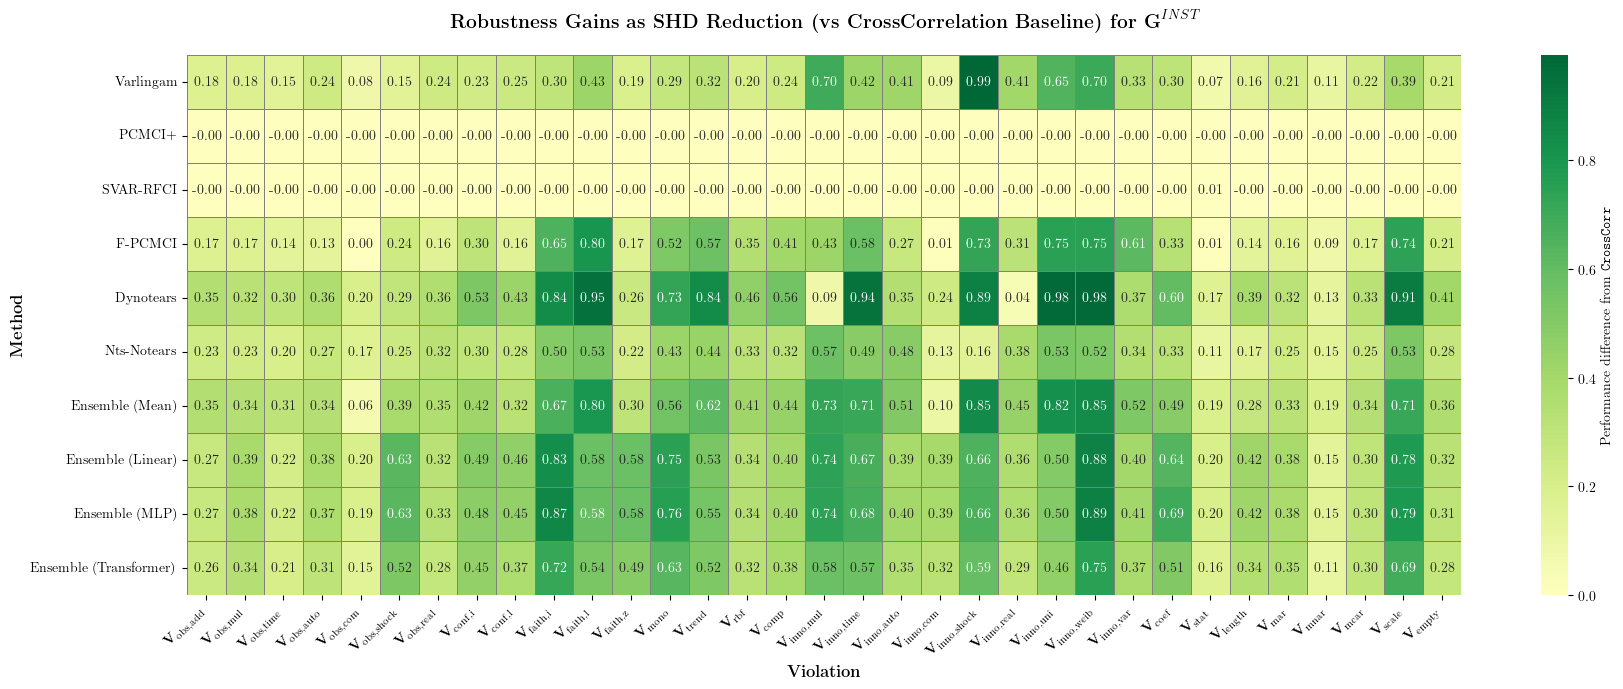

In [52]:
create_gains_heatmap(base2,which="INST",name="INST")

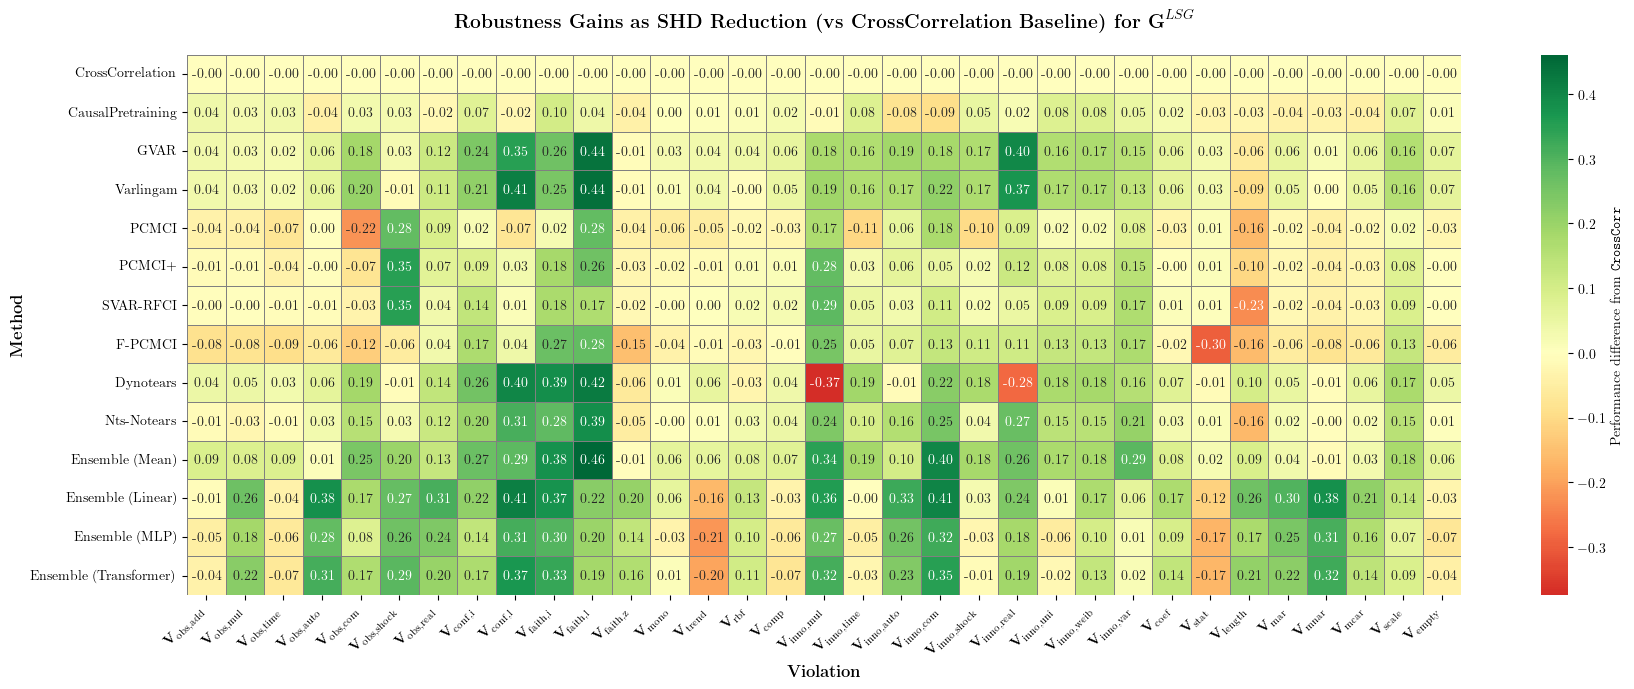

In [53]:
create_gains_heatmap(base3,which="SG_max",name="LSG")